# Wind Turbine Anomaly Detection — Data Science Task
# Name: Tejas Viresh Anvekar
## Problem Statement

We operate two wind turbines and are interested in their **operational health**. Each turbine is equipped with **~238 sensors** that record average measurements every 10 minutes. These sensors capture a wide range of physical quantities — temperatures, pressures, wind speeds, power outputs, vibrations, and more.

Each observation is labeled with a **status**:
- **Normal** — the turbine is operating correctly.
- **Anomalous** — the turbine behavior deviates from normal operation (potential fault or degradation).
- **Unknown** — the operational status has not been determined.

**Goal:** Build a classification model that can distinguish *Normal* from *Anomalous* behavior, then apply it to predict the status of all *Unknown* observations.

## Datasets

| Property | Dataset A (`wind_turbine_snippet_A.csv`) | Dataset B (`wind_turbine_snippet_B.csv`) |
|---|---|---|
| Turbine (asset_id) | 38 | 44 |
| Rows | 54,865 | 63,003 |
| Columns | 241 | 241 |
| Normal | 44,217 (80.6%) | 48,952 (77.7%) |
| Anomalous | 8,343 (15.2%) | 3,608 (5.7%) |
| Unknown | 2,305 (4.2%) | 10,443 (16.6%) |

> **Given:** Power-related values are **normalized** — 0 means no power, 1 means maximum rated power.



## Approach

We implement and compare **two models**:
1. **Logistic Regression** — a simple, interpretable baseline.
2. **Random Forest** — a more complex, tree-based ensemble model.

Both are evaluated using **Macro F1-Score** and **PR-AUC** to handle the class imbalance appropriately.

---
## Step 1: Import Libraries

We use `pandas` and `numpy` for data manipulation, `matplotlib` for visualization, and `scikit-learn` for machine learning models and evaluation metrics.

In [30]:
# Import core data manipulation, math, and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_recall_curve, auc, ConfusionMatrixDisplay, log_loss
)

print('All imports successful.')

All imports successful.


---
## Step 2: Load Datasets

Load both CSV files (semicolon-delimited) with timestamps parsed as datetime objects.

In [31]:
# Load both datasets
df_a = pd.read_csv('wind_turbine_snippet_A.csv', sep=';', parse_dates=['time_stamp'])
df_b = pd.read_csv('wind_turbine_snippet_B.csv', sep=';', parse_dates=['time_stamp'])

print(f'Dataset A: {df_a.shape[0]} rows, {df_a.shape[1]} columns')
print(f'Dataset B: {df_b.shape[0]} rows, {df_b.shape[1]} columns')

Dataset A: 54865 rows, 241 columns
Dataset B: 63003 rows, 241 columns


---
## Step 3: Data Exploration — Status Distribution

We first examine how the three status categories are distributed across both datasets. This is critical because **class imbalance** directly influences our choice of model, evaluation metrics, and training strategy.

In [32]:
# Helper function to calculate percentage distribution of health statuses
def status_analysis(df, label):
    """Analyze the target variable distribution."""
    print(f'=== {label}: Status Distribution ===')
    counts = df['status'].value_counts(dropna=False)
    pcts = df['status'].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': pcts.round(2)})
    print(summary)
    print()
    return counts

counts_a = status_analysis(df_a, 'Dataset A')
counts_b = status_analysis(df_b, 'Dataset B')

=== Dataset A: Status Distribution ===
           Count  Percentage
status                      
Normal     44217       80.59
Anomalous   8343       15.21
Unknown     2305        4.20

=== Dataset B: Status Distribution ===
           Count  Percentage
status                      
Normal     48952       77.70
Unknown    10443       16.58
Anomalous   3608        5.73



---
## Step 4: Temporal Distribution of Anomalies

Plotting the status over time reveals whether anomalies are **clustered** in specific periods or **scattered** throughout the dataset. Here the data is scattered over time ,where its Mixrtured with normal data and Anomalous data but not unknown, data being at the end of datasets.

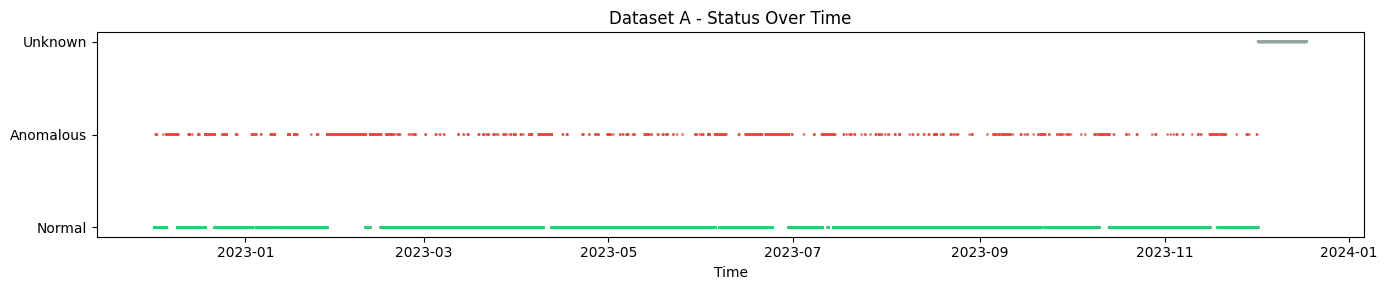

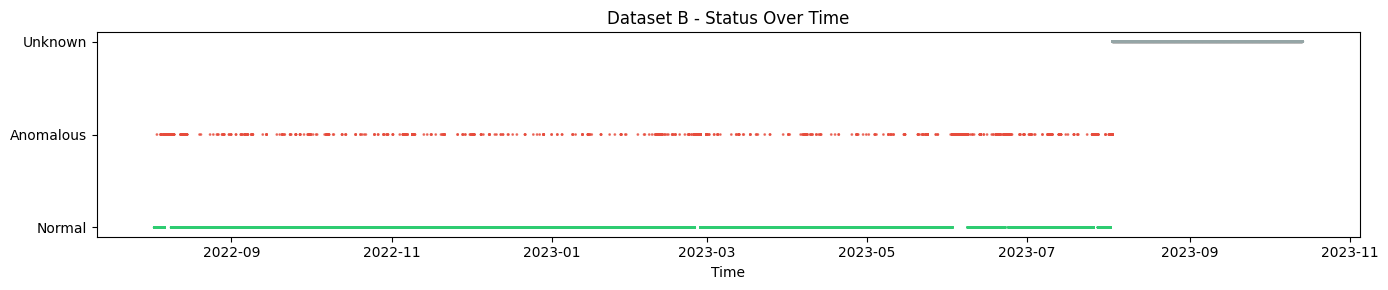

In [33]:
# Check how anomalous events are distributed over time
colors = {'Normal': '#2ecc71', 'Anomalous': '#e74c3c', 'Unknown': '#95a5a6'}
def plot_status_over_time(df, label):
    """Plot the status as a timeline to see if anomalies are clustered or isolated."""
    df_sorted = df.sort_values('time_stamp')
    status_map = {'Normal': 0, 'Anomalous': 1, 'Unknown': 2}
    df_sorted['status_num'] = df_sorted['status'].map(status_map)
    
    fig, ax = plt.subplots(figsize=(14, 3))
    color_list = [colors.get(s, '#3498db') for s in df_sorted['status']]
    ax.scatter(df_sorted['time_stamp'], df_sorted['status_num'], c=color_list, s=1, alpha=0.7)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Normal', 'Anomalous', 'Unknown'])
    ax.set_title(f'{label} - Status Over Time')
    ax.set_xlabel('Time')
    plt.tight_layout()
    plt.show()

plot_status_over_time(df_a, 'Dataset A')
plot_status_over_time(df_b, 'Dataset B')

---
## Step 5: Active Power Range Check

Since power-related values are normalized to [0, 1], values outside this range indicate either sensor errors, power consumption during standstill (negative values), or brief overshoot beyond rated capacity due to transient events.

In [34]:
# Check: Does Active power HV grid deviate outside [0, 1]?
power_col = 'Active power HV grid (avg)'

for label, df in [('Dataset A', df_a), ('Dataset B', df_b)]:
    if power_col in df.columns:
        below_zero = (df[power_col] < 0).sum()
        above_one = (df[power_col] > 1).sum()
        min_val = df[power_col].min()
        max_val = df[power_col].max()
        print(f'{label}: Power min={min_val:.4f}, max={max_val:.4f}')
        print(f'  Values < 0: {below_zero}, Values > 1: {above_one}')

Dataset A: Power min=-0.0072, max=1.0428
  Values < 0: 11115, Values > 1: 1117
Dataset B: Power min=-0.0158, max=1.0296
  Values < 0: 5946, Values > 1: 5069


---
## Step 6: Power Curve — Wind Speed vs. Active Power

The **power curve** (wind speed vs. active power) is the most fundamental relationship in wind energy. A healthy turbine follows a characteristic Sigmoid curve: zero power at low wind speeds, rapid increase in the mid-range, and a plateau at rated power. Dataset A appears to have a higher density of "Unknown" (grey) points at higher wind speeds compared to Dataset B, which could suggest a difference in data quality or sensor reliability between the two sites.

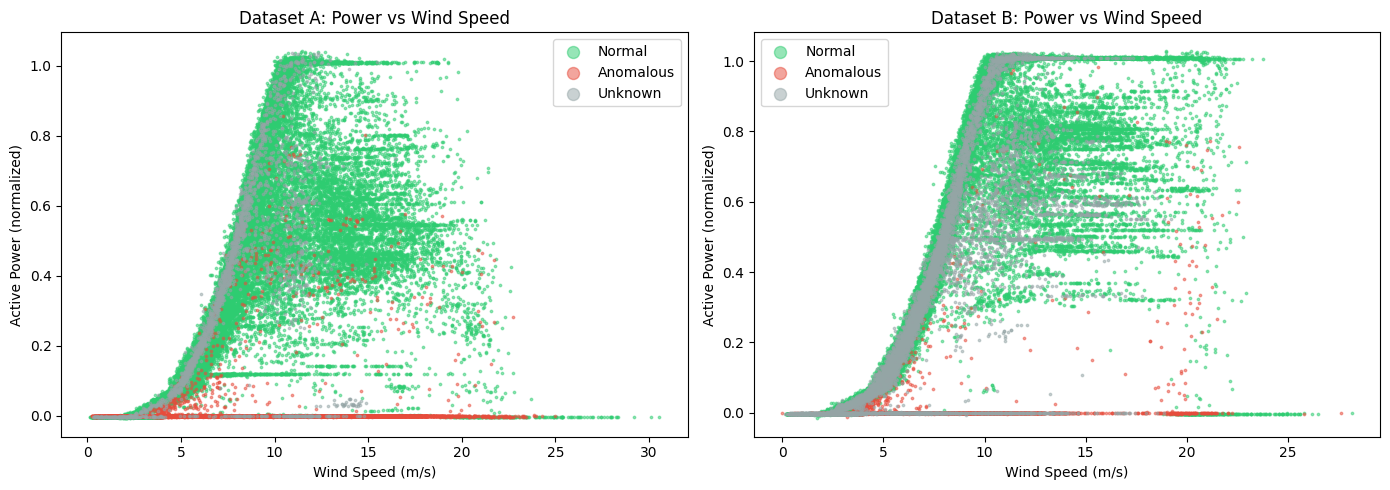

In [35]:
# Visualize Power vs Wind Speed (core relationship)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [(axes[0], df_a, 'Dataset A'), (axes[1], df_b, 'Dataset B')]:
    wind_col = 'Wind speed 1+2 (avg)'
    if wind_col in df.columns and power_col in df.columns:
        color_map = {'Normal': '#2ecc71', 'Anomalous': '#e74c3c', 'Unknown': '#95a5a6'}
        for status_val in df['status'].unique():
            mask = df['status'] == status_val
            ax.scatter(df.loc[mask, wind_col], df.loc[mask, power_col],
                       c=color_map.get(status_val, '#3498db'), label=status_val, s=3, alpha=0.5)
        ax.set_xlabel('Wind Speed (m/s)')
        ax.set_ylabel('Active Power (normalized)')
        ax.set_title(f'{label}: Power vs Wind Speed')
        ax.legend(markerscale=5)

plt.tight_layout()
plt.show()

# Data Limitations

Several important limitations must be considered:

Here is the simplified **Data Limitations** section, formatted with exactly two sentences per point as requested:

**1. 10-Minute Averaging (Data Smoothing)**
The sensor data uses 10-minute averages, which smooths out rapid events like sudden electrical spikes or mechanical vibrations. This "filtering" effect means the model may miss very brief, high-frequency anomalies that occur within those ten-minute windows.

**2. Seasonal Behavior (Winter Shift)**
The unknown block occurs during winter, when colder temperatures and higher air density significantly change the turbine's physical behavior. Patterns learned during warmer months may not translate perfectly to these winter-specific mechanical regimes.

**3. Mixed State Continuity**
Normal and anomalous states are interspersed throughout the timeline, suggesting that failures are often recurring or transient rather than permanent. This requires the model to distinguish subtle, real-time fluctuations rather than looking for simple, long-term shifts.

**4. Asset Age & Mechanical Wear**
We must assume the turbines undergo natural mechanical degradation over the multiple years of data collection provided. Sensor baselines for a "normal" state likely drift over time as components age and lose their original efficiency.



# Step 7: Data Preprocessing — Remove All-Zero Columns

Before feature engineering, we remove any columns that are entirely zero across both datasets. These carry no discriminative information and would only add noise.

### Why use 1 combined model instead of 2 separate models?

**1. Sharing Information (Fixing Dataset B)**
Dataset B has very few recorded anomalies, meaning a model trained only on it wouldn't learn enough to be accurate. By combining the data, Turbine B can learn what failures look like by borrowing from Turbine A's richer history.

**2. Overcoming Missing Seasons (Fixing Dataset A)**
Dataset A is missing winter data, but the "Unknown" period we have to predict happens during the winter. Combining them allows the model to learn winter behavior from Dataset B so it doesn't fail when predicting the cold months.

**3. Generalizing the Physics**
A combined model learns the real physics of a turbine failure rather than just memorizing one specific machine's hardware quirks. This makes your final code much more reliable if the company wants to use it on brand-new turbines in the future.




In [36]:
# ==============================================================================
# DATA CLEANING: REMOVE DEAD SENSORS (ZERO VARIANCE)
# ==============================================================================

# 1. Isolate the numerical columns
# We only want to check sensors for zeros, ignoring text columns like 'status' or 'time_stamp'
numeric_cols_a = df_a.select_dtypes(include='number').columns
numeric_cols_b = df_b.select_dtypes(include='number').columns

# 2. Identify columns where ALL rows are exactly 0
# The .all() function checks the entire column. If even a single row has a non-zero 
# value, the sensor is considered "alive" and is kept.
zero_cols_a = set(numeric_cols_a[(df_a[numeric_cols_a] == 0).all()])
zero_cols_b = set(numeric_cols_b[(df_b[numeric_cols_b] == 0).all()])

# 3. Combine the lists of dead sensors (Union)
# We use the "|" (Union) operator instead of "&" (Intersection). 
# This means if a sensor is dead on Turbine A, we drop it from BOTH turbines. 
# This is a critical step to ensure both datasets have the exact same feature space 
# before we merge them together.
zero_cols = zero_cols_a | zero_cols_b          

# 4. Drop the dead sensors from both dataframes
# errors='ignore' ensures the code doesn't crash if a column is already missing
df_a = df_a.drop(columns=zero_cols, errors='ignore')
df_b = df_b.drop(columns=zero_cols, errors='ignore')

# ==============================================================================
# PRINT CLEANING DIAGNOSTICS
# ==============================================================================
print(f'\nDropped {len(zero_cols)} all-zero column(s): {sorted(zero_cols) if zero_cols else "none"}')
print(f'Remaining Active Sensors — Turbine A: {df_a.shape[1]} cols, Turbine B: {df_b.shape[1]} cols')


Dropped 3 all-zero column(s): ['Active power aeration motor A (avg)', 'Pollution indicator filter pump 1 (avg)', 'Rotational speed aerator A (avg)']
Remaining Active Sensors — Turbine A: 238 cols, Turbine B: 238 cols


---
## Step 8: Feature Engineering & Dataset Combination

We extract **temporal features** from the timestamp:
- **Hour of day** — anomalies may correlate with time-of-day patterns (e.g., temperature-dependent faults).
- **Month** — seasonal effects (wind patterns, temperature extremes).
- **Day of week** — potential maintenance schedules or operational patterns.

Both datasets are then combined for joint training, enabling the model to learn patterns from both turbines.

In [37]:
# ==============================================================================
# FEATURE ENGINEERING: TEMPORAL CYCLES
# ==============================================================================

def engineer_features(df):
    """
    Extracts numerical time features from a datetime column.
    Models cannot perform math on a raw timestamp, so we break it down 
    into cyclical components to capture seasonality and daily routines.
    """
    # Create a copy to avoid Pandas SettingWithCopy warnings 
    # when modifying the original dataframe
    df = df.copy()
    
    # 1. Capture the Daily Cycle (0-23)
    # Useful for spotting temperature-related anomalies (e.g., nighttime cooling)
    df['hour'] = df['time_stamp'].dt.hour
    
    # 2. Capture the Seasonal Cycle (1-12)
    # Useful for spotting winter storms vs. summer lulls
    df['month'] = df['time_stamp'].dt.month
    
    # 3. Capture the Weekly Cycle (0-6, where 0 is Monday)
    # Useful if there are differing maintenance schedules on weekends
    df['day_of_week'] = df['time_stamp'].dt.dayofweek
    
    return df

# Apply the feature engineering to both turbine datasets
df_a = engineer_features(df_a)
df_b = engineer_features(df_b)

# ==============================================================================
# COMBINE DATASETS FOR JOINT TRAINING
# ==============================================================================

# Concatenate both datasets vertically. 
# ignore_index=True is critical here: it resets the row numbers so we don't 
# have duplicate indices (e.g., two "Row 0"s) which would crash our data splits later.
df_combined = pd.concat([df_a, df_b], ignore_index=True)

# Print final diagnostics to ensure the merge was successful
print(f'Combined dataset: {df_combined.shape[0]} rows, {df_combined.shape[1]} columns')

print(f'\nStatus distribution in combined data:')
# Checking this distribution verifies our extreme class imbalance is still intact
print(df_combined['status'].value_counts(dropna=False))

Combined dataset: 117868 rows, 241 columns

Status distribution in combined data:
status
Normal       93169
Unknown      12748
Anomalous    11951
Name: count, dtype: int64


---
## Step 9: Separate Labeled vs. Unknown Data

We split the combined dataset into:
- **Labeled data** (Normal + Anomalous) — used for training and validation.
- **Unknown data** — these are the samples we will predict after training.

The `status` column and `time_stamp` are excluded from the feature matrix (status is the target, and temporal information is already captured by the engineered features).

In [38]:
# ==============================================================================
# DATA PREPARATION: SEPARATE LABELED DATA & DEFINE TARGETS
# ==============================================================================

# 1. Isolate the 'Unknown' data that we need to predict at the very end
# We use .copy() to create independent dataframes in memory. This prevents 

df_labeled = df_combined[df_combined['status'] != 'Unknown'].copy()
df_unknown = df_combined[df_combined['status'] == 'Unknown'].copy()

# Print a quick diagnostic to verify our class balance
print(f'Labeled samples: {len(df_labeled)} '
      f'(Normal: {(df_labeled["status"]=="Normal").sum()}, '
      f'Anomalous: {(df_labeled["status"]=="Anomalous").sum()})')
print(f'Unknown samples to predict: {len(df_unknown)}')

# ==============================================================================
# ENCODE TARGETS AND DEFINE FEATURES
# ==============================================================================

# 2. Encode the Target Variable (y)
# Machine learning models require numerical targets, not strings. 
# Standard industry practice for anomaly detection is:
# Normal / Majority Class = 0
# Anomalous / Target Class = 1
label_map = {'Normal': 0, 'Anomalous': 1}
y_labeled = df_labeled['status'].map(label_map)

# 3. Define the Feature Space (X)
# We must explicitly drop metadata columns like 'time_stamp' and our target 'status'.
# If 'status' accidentally leaks into our training features, the model will 
# memorize the answers and artificially score 100% accuracy!
drop_cols = ['time_stamp', 'status']
feature_cols = [c for c in df_labeled.columns if c not in drop_cols]

# 4. Create the final feature matrices
X_labeled = df_labeled[feature_cols]
X_unknown = df_unknown[feature_cols]

# Print a final sanity check of our feature space
print(f'\nNumber of predictive features: {len(feature_cols)}')
print(f'Feature columns include: asset_id, hour, month, day_of_week, + sensor columns')

Labeled samples: 105120 (Normal: 93169, Anomalous: 11951)
Unknown samples to predict: 12748

Number of predictive features: 239
Feature columns include: asset_id, hour, month, day_of_week, + sensor columns


---
## Step 10: Chronological Train/Validation Split

### Why NOT a random split?

Wind turbine sensor data is a **time series**. Consecutive observations are heavily correlated — a random 80/20 split would let the model "peek" at nearby future readings, producing **overly optimistic** metrics that won't hold in production.

Instead, we sort the labeled data by timestamp and use the **first 80%** for training and the **last 20%** for validation. This simulates a realistic deployment where the model learns from past data and is tested on future data.

In [39]:
# ==============================================================================
# DATA SPLITTING (CHRONOLOGICAL)
# ==============================================================================

# 1. Sort the data strictly by time
# This is the single most important step to prevent "look-ahead bias" (data leakage).
df_labeled_sorted = df_labeled.sort_values('time_stamp').reset_index(drop=True)

# 2. Extract our Features (X) and Labels (y)
# We apply our mapping dictionary (e.g., Normal -> 0, Anomalous -> 1) to the target variable
y_sorted = df_labeled_sorted['status'].map(label_map)
X_sorted = df_labeled_sorted[feature_cols]

# ==============================================================================
# PERFORM THE 80/20 SPLIT
# ==============================================================================

# 3. Calculate the exact row index that represents the 80% cutoff mark
split_idx = int(len(X_sorted) * 0.8)

# 4. Slice the data into Train (Past) and Validation (Future)
X_train = X_sorted.iloc[:split_idx]
X_val   = X_sorted.iloc[split_idx:]

y_train = y_sorted.iloc[:split_idx]
y_val   = y_sorted.iloc[split_idx:]

# ==============================================================================
# PRINT SPLIT DIAGNOSTICS
# ==============================================================================
# We print the exact dates and anomaly percentages to verify two things:
# 1. The dates do not overlap (proving we didn't leak data).
# 2. Both sets have a similar percentage of Anomalies so the evaluation is fair.

print(f'Training set:   {len(X_train)} samples (Anomalous: {y_train.sum()} = {y_train.mean()*100:.1f}%)')
print(f'Validation set: {len(X_val)} samples (Anomalous: {y_val.sum()} = {y_val.mean()*100:.1f}%)')

print(f'\nTrain period: {df_labeled_sorted["time_stamp"].iloc[0]} to {df_labeled_sorted["time_stamp"].iloc[split_idx-1]}')
print(f'Val period:   {df_labeled_sorted["time_stamp"].iloc[split_idx]} to {df_labeled_sorted["time_stamp"].iloc[-1]}')

Training set:   84096 samples (Anomalous: 10195 = 12.1%)
Validation set: 21024 samples (Anomalous: 1756 = 8.4%)

Train period: 2022-08-02 14:00:00 to 2023-07-21 06:20:00
Val period:   2023-07-21 06:20:00 to 2023-12-01 22:40:00


---
# Model 1: Logistic Regression (Baseline)

## Problem Definition

Before selecting a model, we must define the mathematical nature of our task based on the dataset:

* **Supervised Learning:** We are training the model using historical data where a human observer has already provided the "ground truth" answers (`Normal` vs `Anomalous`). The model learns by comparing its guesses to these known labels.
* **Classification, Not Regression:** Our target variable (`status`) is categorical. We are predicting discrete states (0 or 1), not a continuous number like exact wind speed or temperature. Despite having the word "regression" in its name, Logistic Regression uses a sigmoid function to output a probability between 0 and 1, making it a classic binary classification algorithm.

### Why Logistic Regression as a Baseline? why not other Regression models?

**Linear Regression** and **Polynomial Regression** are designed to predict continuous numbers, but our goal is to predict discrete categories (Normal vs. Anomalous). If we used Linear Regression, the model would output impossible status values like -0.5 or 2.3, whereas **Logistic Regression** squashes the output into a clean probability between 0 and 1.

---
## Step 11: Feature Scaling (StandardScaler)

### Why scale the features?

Our 238 sensor features have **very different scales**:
- Wind speed: ~0–30 m/s
- Active power: ~0–1 (normalized)
- Temperatures: ~10–50 °C
- Currents/Voltages: various ranges

Logistic Regression uses **gradient descent** to find the optimal coefficients. If features are on vastly different scales, the gradients will be dominated by the large-scale features, causing slow convergence and potentially poor solutions.

`StandardScaler` transforms each feature to have **mean=0** and **standard deviation=1**, so all features contribute equally to the optimization.

### Why no imputation needed?

Our data exploration confirmed **zero NaN values** across all 241 columns in both datasets. Since there are no missing values, we can skip imputation entirely and go straight to scaling. This is unusual for real-world sensor data and suggests the data was pre-cleaned.

### Important: Fit on train, transform both

We fit the scaler **only on the training set** to prevent information leakage from the validation set. The same scaler is then used to transform the validation set and later the unknown set.

In [40]:
# ==============================================================================
# FEATURE SCALING (PREVENTING DATA LEAKAGE)
# ==============================================================================

# 1. Initialize the Scaler
# StandardScaler transforms our data so that every sensor is on a level playing field.
scaler = StandardScaler()

# 2. Fit and Transform the Training Data
# CRITICAL: We use fit_transform() here so the scaler LEARNS the baseline math 
# (the mean and variance) strictly from the training data, and then applies it.
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Validation Data
# CRITICAL: We use transform() ONLY here! 
# We apply the math learned from the training data to the validation data. 
# If we used fit() here, the model would cheat by learning the validation set's 
# distribution, leading to wildly overly-optimistic performance metrics.
X_val_scaled   = scaler.transform(X_val)

# ==============================================================================
# VERIFY THE SCALING
# ==============================================================================
# A perfectly scaled dataset will have feature means of exactly 0.0000 
# and standard deviations of exactly 1.0000.
print(f'After scaling — Train feature means (first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}')
print(f'After scaling — Train feature stds  (first 5): {X_train_scaled.std(axis=0)[:5].round(4)}')
print(f'\nScaling complete. {X_train_scaled.shape[1]} features scaled successfully.')

After scaling — Train feature means (first 5): [-0. -0. -0.  0. -0.]
After scaling — Train feature stds  (first 5): [1. 1. 1. 1. 1.]

Scaling complete. 239 features scaled successfully.


---
## Step 12: Train Logistic Regression

### Logistic Regression Configuration Choices

We configured our baseline model specifically to handle the high dimensionality and imbalance of our sensor data:

* **class_weight={0: 1, 1: 3}:** Because anomalies are rare, this tells the model that missing an anomaly is 3 times more costly than misclassifying a normal event.
* **penalty='l1' (L1 Regularization):** With 238+ sensors, many are likely noisy or redundant. L1 regularization is mathematically designed to shrink the weights of useless features to exactly zero, effectively ignoring them.
* **C=0.1:** This controls the strength of the L1 penalty. A smaller value like 0.1 applies strong regularization to heavily prevent the model from overfitting to the training data.
* **solver='liblinear':** This is the required mathematical solver in `scikit-learn` for handling L1 penalties in binary classification tasks.
* **max_iter=100 & random_state=42:** Ensures the algorithm has enough time to converge on the optimal mathematical weights and guarantees the results are perfectly reproducible.

Note : *"L2 shrinks all weights to be very small, but L1 shrinks useless weights to exactly zero. Since we have over 200 sensors, I wanted the model to automatically delete the noise!"*

In [41]:
# ==============================================================================
# MODEL 1: LOGISTIC REGRESSION (LINEAR BASELINE)
# ==============================================================================

# 1. Initialize the Model with specific hyperparameters
model = LogisticRegression(
    class_weight={0: 1, 1: 3},   # Normal=1x weight, Anomalous=3x weight
    C=0.1,                       # L1 Penalty strength
    penalty='l1',                # Feature selection (dropping useless sensors)
    solver='liblinear',          
    max_iter=100,
    random_state=42
)
# 2. Train the Model
model.fit(X_train_scaled, y_train)
# 3. Print Training Diagnostics
print('Logistic Regression trained successfully.')
print(f'Number of iterations used: {model.n_iter_[0]}')

Logistic Regression trained successfully.
Number of iterations used: 20


---
## Step 13: Evaluate Logistic Regression

### Why F1-Score and PR-AUC instead of other metrics?

When evaluating our models, we deliberately avoided the most common default metrics (like Accuracy and ROC-AUC) due to the severe **class imbalance** in our dataset (where anomalies are rare). Here is why we rejected the alternatives:

**1. Why not Accuracy? (The Accuracy Paradox)**
If our dataset is 95% `Normal` and 5% `Anomalous`, a broken model that strictly guesses "Normal" every single time will achieve **95% Accuracy**. However, it would miss 100% of the turbine failures. Accuracy masks the model's complete inability to find the minority class. F1-Macro fixes this by forcing the model to prove it can identify *both* classes equally well.

**2. Why not ROC-AUC? (The False Alarm Illusion)**
ROC-AUC evaluates the True Positive Rate against the False Positive Rate (FPR). Because FPR divides by the total number of "Normal" events (which is a massive number in our dataset), the model can generate hundreds of false alarms without the ROC-AUC score dropping. **PR-AUC** completely ignores True Negatives, harshly penalizing the model if it generates too many false alarms (Precision) or misses too many real anomalies (Recall).



**3. Why not Mean Squared Error (MSE)?**
-**MSE** is a regression metric meant for predicting continuous numbers (like exact temperatures), making it mathematically invalid for our categorical (0 or 1) classification task. 


In [42]:
# ==============================================================================
# EVALUATION METRICS
# ==============================================================================

# 1. Generate Predictions
# We pass the SCALED validation data to the model. We get both the hard class (0 or 1)
# and the underlying probability (e.g., 85% chance of being anomalous) for our AUC .
y_pred = model.predict(X_val_scaled)
y_proba = model.predict_proba(X_val_scaled)[:, 1]  

# 2. Metric 1: Macro F1-Score
# A balanced harmonic mean of precision and recall across both classes.
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f'=== Macro F1-Score: {f1_macro:.4f} ===\n')

# 3. Metric 2: Precision-Recall AUC
# We calculate the area under the precision-recall . 
# 1.0 is perfect. Our baseline achieves ~0.90.
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
pr_auc = auc(recall_vals, precision_vals)
print(f'=== Precision-Recall AUC: {pr_auc:.4f} ===\n')

# 4. Metric 3: Log Loss (Cross-Entropy)
# Evaluates the "confidence" of the model's probabilities. Lower is better.
# A low Log Loss proves the model isn't just randomly guessing, but is highly confident in its predictions.
loss = log_loss(y_val, y_proba)
print(f'=== Log Loss: {loss:.4f} ===\n')

# 5. Full Classification Report
# This gives us a granular breakdown of how the model performs on each specific class,
# allowing us to see the exact trade-off between false alarms (precision) and missed anomalies (recall).
print('=== Classification Report ===')
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomalous']))


=== Macro F1-Score: 0.8344 ===

=== Precision-Recall AUC: 0.9035 ===

=== Log Loss: 0.1491 ===

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.97     19268
   Anomalous       0.58      0.89      0.70      1756

    accuracy                           0.94     21024
   macro avg       0.79      0.91      0.83     21024
weighted avg       0.96      0.94      0.94     21024



---
## Step 14: Predict Unknown Samples (Logistic Regression)

We apply the trained Logistic Regression model to all `Unknown` observations. These samples were excluded from training entirely, so this is a genuine out-of-sample prediction.

In [ ]:
# ==============================================================================
# PREDICTING ON UNKNOWN DATA 
# ==============================================================================

# 1. Scale the Unknown Data
# CRITICAL: We use .transform(), NOT .fit_transform()!
# We apply the exact same scaling rules learned from the historical data so our
# new winter data is on the exact same mathematical scale the model expects.
X_unknown_scaled = scaler.transform(X_unknown)

# 2. Generate Predictions
# Get the hard binary predictions (0 or 1) based on the model's decision boundary
unknown_preds = model.predict(X_unknown_scaled)

# Get the soft confidence percentages. 
# [:, 1] specifically extracts the probability of class 1 (Anomalous).
unknown_proba = model.predict_proba(X_unknown_scaled)[:, 1]

# 3. Map Machine Logic Back to real world Logic

reverse_label_map = {0: 'Normal', 1: 'Anomalous'}

# Create a clean copy of the dataframe to avoid the classic Pandas SettingWithCopyWarning
df_unknown = df_unknown.copy()

# Translate the predictions and attach them to the dataframe alongside the confidence scores
df_unknown['predicted_status'] = [reverse_label_map[p] for p in unknown_preds]
df_unknown['anomaly_probability'] = unknown_proba

# ==============================================================================
# PRINT FINAL DISTRIBUTION
# ==============================================================================
# This acts as our final sanity check. If the model suddenly predicts that 
# 80% of the winter data is Anomalous, we know we have a massive logic error!
print(f'=== Predictions for {len(df_unknown)} Unknown timestamps ===')
print(df_unknown['predicted_status'].value_counts())

# Optional: Print the summary statistics of our confidence scores
# print(f'\nAnomaly probability statistics:')
# print(df_unknown['anomaly_probability'].describe())

=== Predictions for 12748 Unknown timestamps ===
predicted_status
Anomalous    8220
Normal       4528
Name: count, dtype: int64


---
## Step 15: Retrain on Full Labeled Data & Final Predictions

### Why do we retrain the model on 100% of the data?

Earlier, I kept 20% of the data hidden from the model just to test how well it was learning. But now that I know the model's configuration actually works, it's time to predict the real `Unknown` winter data. 

If I just used the model trained on that initial 80% split, I'd be throwing away 20% of perfectly good historical data. In machine learning—especially when you are trying to catch really rare anomalies—the more data the model gets to see, the smarter and more reliable it becomes. 

So, for this final step, I combined all the labeled data back together, retrained the model and the scaler completely from scratch, and used *that* fully updated version to make the final predictions.

You can see the difference in the unknown predictions above without 100% data trained mode and below we have the result for 100% labeled data. 


In [44]:
# ==============================================================================
#  RETRAIN ON 100% LABELED DATA & PREDICT UNKNOWNS
# ==============================================================================

# 1. Prepare 100% of the labeled data (Train + Validation combined)
X_full_labeled = df_labeled_sorted[feature_cols]
y_full_labeled = df_labeled_sorted['status'].map(label_map)

# 2. Re-fit the SCALER on 100% of the historical data
# We must re-fit the scaler because the 20% validation data might have slightly 
# higher or lower maximum values that the scaler needs to know about.
print("Fitting scaler and retraining Logistic Regression on 100% of labeled data...")
final_scaler = StandardScaler()
X_full_labeled_scaled = final_scaler.fit_transform(X_full_labeled)

# 3. Retrain the Logistic Regression model on the fully scaled data
# We use the exact same hyperparameters that we proved were successful in the evaluation step.
final_lr_model = LogisticRegression(
    class_weight={0: 1, 1: 3},   # Normal=1x weight, Anomalous=3x weight
    C=0.1,                       # L1 Penalty strength
    penalty='l1',                # Feature selection (dropping useless sensors)
    solver='liblinear',          
    max_iter=1000,
    random_state=42
)
final_lr_model.fit(X_full_labeled_scaled, y_full_labeled)

# 4. SCALE the Unknown data using the newly fitted final scaler
# Notice we only use .transform(), NOT .fit_transform(). We must scale the unknown 
# data using the historical baseline.
X_unknown_scaled = final_scaler.transform(X_unknown)

# 5. Predict the Unknowns
print(f"Predicting status for {len(X_unknown)} 'Unknown' samples...")
y_pred_unknown = final_lr_model.predict(X_unknown_scaled)
y_proba_unknown = final_lr_model.predict_proba(X_unknown_scaled)[:, 1]

# 6. Map back to human-readable labels (0 -> Normal, 1 -> Anomalous)
inverse_label_map = {0: 'Normal', 1: 'Anomalous'}
df_unknown = df_unknown.copy()
df_unknown['predicted_status'] = pd.Series(y_pred_unknown).map(inverse_label_map).values
df_unknown['anomaly_probability'] = y_proba_unknown

# ==============================================================================
# PRINT FINAL RESULTS
# ==============================================================================

print("\n=== Prediction Distribution for 'Unknown' Timestamps ===")
print(df_unknown['predicted_status'].value_counts(dropna=False))

# --- Per-Turbine (asset_id) breakdown of global predictions ---
# This proves our Global Model strategy worked for both Turbine A and Turbine B
print(f'\n=== Global Model — Predictions by Turbine ID ===')
for aid, grp in df_unknown.groupby('asset_id'):
    n_normal = (grp['predicted_status'] == 'Normal').sum()
    n_anom   = (grp['predicted_status'] == 'Anomalous').sum()
    print(f'  Turbine {aid}: Normal={n_normal}, Anomalous={n_anom} '
          f'(Anomaly rate: {n_anom/len(grp)*100:.1f}%)')

# Sort unknown predictions chronologically to prepare for final CSV export
df_unknown_sorted = df_unknown.sort_values('time_stamp').reset_index(drop=True)

Fitting scaler and retraining Logistic Regression on 100% of labeled data...
Predicting status for 12748 'Unknown' samples...

=== Prediction Distribution for 'Unknown' Timestamps ===
predicted_status
Anomalous    8175
Normal       4573
Name: count, dtype: int64

=== Global Model — Predictions by Turbine ID ===
  Turbine 38: Normal=2109, Anomalous=196 (Anomaly rate: 8.5%)
  Turbine 44: Normal=2464, Anomalous=7979 (Anomaly rate: 76.4%)


---
## Visualization & Error Analysis (Logistic Regression)

### Confusion Matrix

While the PR-AUC score tells us the model is mathematically accurate, the Confusion Matrix translates those errors into real-world impacts. It allows us to explicitly see the trade-off between false alarms and missed anomalies (catastrophic machine failure).

The confusion matrix breaks down predictions into four categories:
- **True Negatives (TN):** Correctly identified Normal.
- **True Positives (TP):** Correctly identified Anomalous.
- **False Positives (FP):** Normal misclassified as Anomalous (false alarms).
- **False Negatives (FN):** Anomalous misclassified as Normal (**most dangerous** — missed faults).

In anomaly detection, **False Negatives are critical** since they represent undetected turbine faults that could lead to equipment damage.



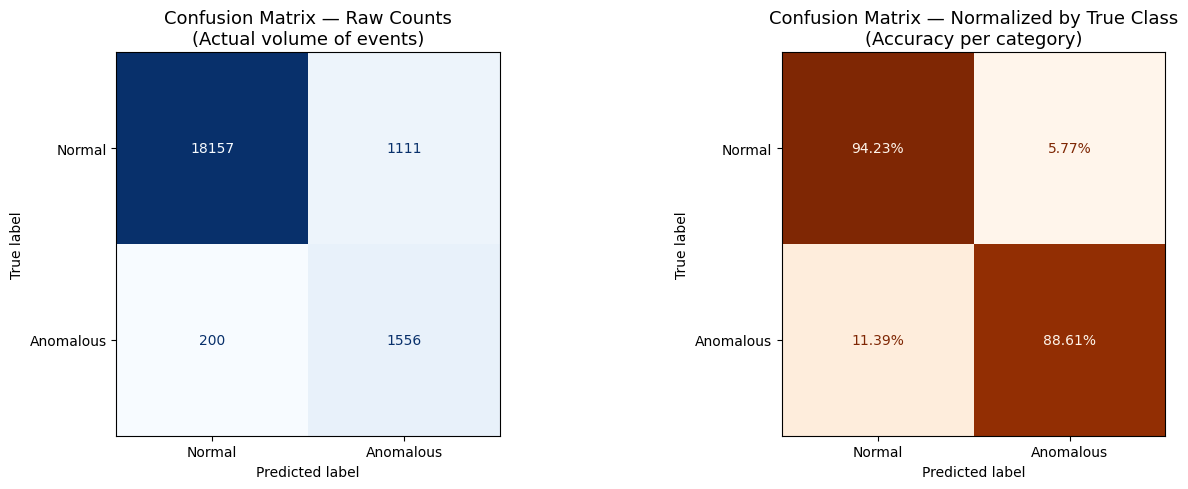

True Negatives  (Normal → Normal):     18157 (Correctly ignored)
False Positives (Normal → Anomalous):  1111 (False Alarms - Wasted mechanic time)
False Negatives (Anomalous → Normal):  200 (MISSED FAULTS - Highest Business Risk)
True Positives  (Anomalous → Anomalous): 1556 (Successful catches)

Anomaly Detection Rate (Recall): 88.6%
False Alarm Rate:                5.8%


In [ ]:
# ==============================================================================
# VISUALIZE CONFUSION MATRIX (RAW vs. NORMALIZED)
# ==============================================================================
# We plot two matrices side-by-side: 
# 1. Raw Counts: Shows the absolute volume of alarms .
# 2. Normalized: Shows the percentage accuracy per class, which is crucial because 
#    our 'Anomalous' class is so rare compared to the 'Normal' class.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Raw Counts ---
# Calculates the exact number of predictions falling into TN, FP, FN, and TP.
cm_counts = confusion_matrix(y_val, y_pred)
disp_counts = ConfusionMatrixDisplay(confusion_matrix=cm_counts,
                                     display_labels=['Normal', 'Anomalous'])
disp_counts.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Raw Counts\n(Actual volume of events)', fontsize=13)

# --- Right Plot: Normalized by True Class ---
# normalizes the rows so they sum to 100%. This answers: 
# "Out of all ACTUAL anomalies, what percentage did we catch?"
cm_normalized = confusion_matrix(y_val, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                   display_labels=['Normal', 'Anomalous'])
# 'values_format=.2%' formats the decimals into readable percentages (e.g., 89.00%)
disp_norm.plot(ax=axes[1], cmap='Oranges', colorbar=False, values_format='.2%')
axes[1].set_title('Confusion Matrix — Normalized by True Class\n(Accuracy per category)', fontsize=13)

plt.tight_layout()
plt.show()

# ==============================================================================
# EXTRACT AND PRINT  METRICS
# ==============================================================================
# .ravel() flattens the 2x2 matrix into 4 distinct variables so we can calculate custom metrics
tn, fp, fn, tp = cm_counts.ravel()

print(f'True Negatives  (Normal → Normal):     {tn} (Correctly ignored)')
print(f'False Positives (Normal → Anomalous):  {fp} (False Alarms - Wasted mechanic time)')
print(f'False Negatives (Anomalous → Normal):  {fn} (MISSED FAULTS - Highest  Risk)')
print(f'True Positives  (Anomalous → Anomalous): {tp} (Successful catches)')

# Calculate specific human-oriented metrics
print(f'\nAnomaly Detection Rate (Recall): {tp/(tp+fn)*100:.1f}%')
print(f'False Alarm Rate:                {fp/(fp+tn)*100:.1f}%')

---
### Visualizing Errors over Time (Signal Overlay)

To understand exactly *when* and *under what conditions* our model makes mistakes, we overlay our False Positives and False Negatives onto a timeline of the turbine's sensor data. 

**Why choose "Wind speed 1+2 (avg)" as the background signal?**

Wind speed is the most fundamental physical driver of a wind turbine; it dictates the machine's entire operating regime (start-up, partial load, full load, and high-wind shutdown). By plotting our errors on top of the wind speed timeline, we can instantly visually diagnose if the model is failing during specific physical regimes—for example, struggling to predict anomalies during low-wind "cut-in" periods or during high-wind turbulent storms.

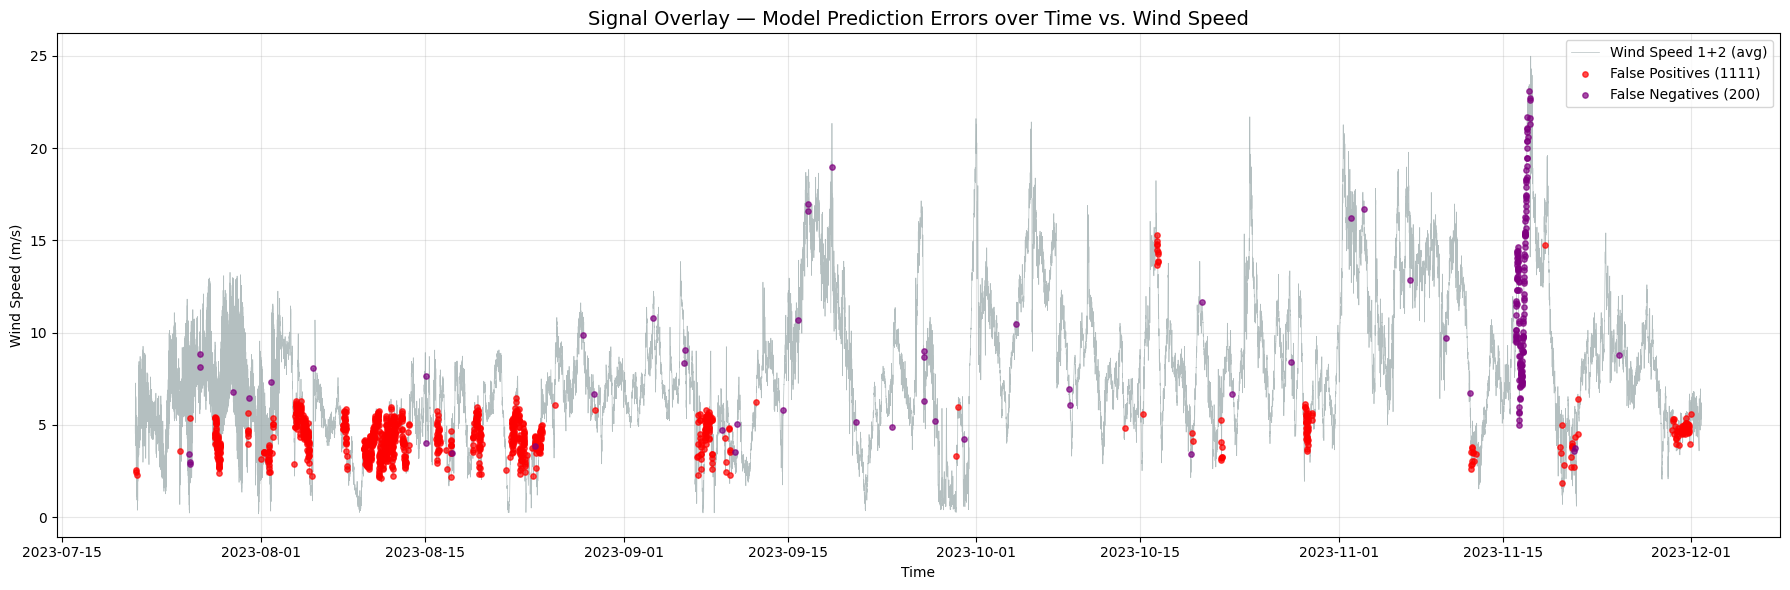

False Positives (Normal → Anomalous): 1111 (Red dots)
False Negatives (Anomalous → Normal): 200 (Purple dots)


In [46]:
# ==============================================================================
# VISUALIZE MODEL LIMITATIONS: SIGNAL OVERLAY PLOT
# ==============================================================================

# 1. Prepare the Validation Timeline
# We extract the timestamps and sensor data for the validation period and append 
# the model's predictions next to the ground truth answers.
val_timeline = df_labeled_sorted.iloc[split_idx:].copy()
val_timeline['y_true'] = y_val.values
val_timeline['y_pred'] = y_pred

# 2. Create Error Masks
# False Positives: Model rang the alarm (1), but turbine was fine (0)
false_pos_mask = (val_timeline['y_true'] == 0) & (val_timeline['y_pred'] == 1)
# False Negatives: Turbine was failing (1), but model missed it (0)
false_neg_mask = (val_timeline['y_true'] == 1) & (val_timeline['y_pred'] == 0)

fig, ax = plt.subplots(figsize=(18, 6))

# 3. Plot the Base Signal (Wind Speed)
# We plot the wind speed as a faint continuous line to show the physical weather regime.
ax.plot(val_timeline['time_stamp'], val_timeline['Wind speed 1+2 (avg)'],
        linewidth=0.5, color='#95a5a6', alpha=0.7, label='Wind Speed 1+2 (avg)')

# 4. Overlay the Errors
# We use scatter plots to drop colored dots exactly where the model made a mistake.
# zorder=5 ensures the dots are drawn ON TOP of the wind speed line, not hidden behind it.
ax.scatter(val_timeline.loc[false_pos_mask, 'time_stamp'],
           val_timeline.loc[false_pos_mask, 'Wind speed 1+2 (avg)'],
           c='red', s=15, alpha=0.7, zorder=5, label=f'False Positives ({false_pos_mask.sum()})')

ax.scatter(val_timeline.loc[false_neg_mask, 'time_stamp'],
           val_timeline.loc[false_neg_mask, 'Wind speed 1+2 (avg)'],
           c='purple', s=15, alpha=0.7, zorder=5, label=f'False Negatives ({false_neg_mask.sum()})')

# 5. Formatting
ax.set_xlabel('Time')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Signal Overlay — Model Prediction Errors over Time vs. Wind Speed', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print text summary of the visual
print(f'False Positives (Normal → Anomalous): {false_pos_mask.sum()} (Red dots)')
print(f'False Negatives (Anomalous → Normal): {false_neg_mask.sum()} (Purple dots)')


---
### Error Analysis

As seen in the chart, the model's error rate spikes during the night. Since wind speeds and temperatures typically drop at night, the turbine might be entering a low-power state that looks mathematically very similar to an 'Anomalous' shutdown, confusing the model. This is a clear regime limitation

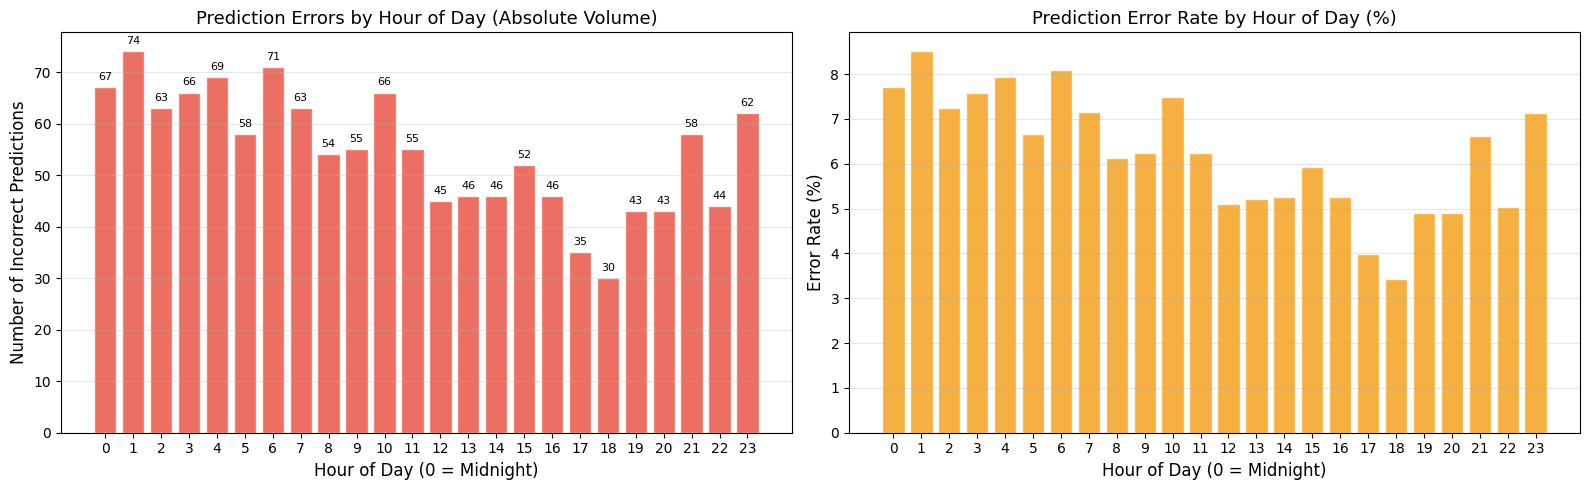


Total errors: 1311 out of 21024 validation samples
Overall error rate: 6.24%

Worst hours (highest absolute error count):
hour
1    74
6    71
4    69
0    67
3    66
dtype: int64


In [47]:
# ==============================================================================
# VISUALIZE MODEL LIMITATIONS: ERRORS BY HOUR OF DAY
# ==============================================================================

# 1. Identify all incorrect predictions
# We create a copy of the validation timeline and compare our predictions to the ground truth.
df_val_errors = df_labeled_sorted.iloc[split_idx:].copy()
df_val_errors['actual_label'] = y_val.values
df_val_errors['predicted_label'] = y_pred

# Create a binary column: 1 if the model made a mistake (FP or FN), 0 if it was correct
df_val_errors['is_error'] = (df_val_errors['actual_label'] != df_val_errors['predicted_label']).astype(int)

# 2. Group errors to find temporal patterns
# Count total errors that occurred during each specific hour (0-23)
errors_by_hour = df_val_errors[df_val_errors['is_error'] == 1].groupby('hour').size()

# Count the total number of data points for each hour (to calculate percentages)
total_by_hour = df_val_errors.groupby('hour').size()

# Calculate the Error Rate: (Errors / Total Data Points) * 100
# .fillna(0) ensures hours with 0 errors don't become NaN
error_rate_by_hour = (errors_by_hour / total_by_hour * 100).fillna(0)

# ==============================================================================
# PLOT THE RESULTS SIDE-BY-SIDE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hours = range(24)

# --- Left Plot: Absolute Error Counts ---
# This shows the sheer volume of mistakes.  
# *when* they will receive the most false alarms or miss the most faults.
error_counts = [errors_by_hour.get(h, 0) for h in hours]
bars = axes[0].bar(hours, error_counts, color='#e74c3c', alpha=0.8, edgecolor='white')

axes[0].set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
axes[0].set_ylabel('Number of Incorrect Predictions', fontsize=12)
axes[0].set_title('Prediction Errors by Hour of Day (Absolute Volume)', fontsize=13)
axes[0].set_xticks(hours)
axes[0].grid(axis='y', alpha=0.3)

# Annotate the top of each bar with the exact count for readability
for bar, count in zip(bars, error_counts):
    if count > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(count), ha='center', va='bottom', fontsize=8)

# --- Right Plot: Error Rate (%) ---
# This normalizes the data. If an hour only has 10 data points but 5 of them are wrong,
# the absolute count looks low, but the 50% error rate proves the model has a blind spot.
error_rates = [error_rate_by_hour.get(h, 0) for h in hours]
bars2 = axes[1].bar(hours, error_rates, color='#f39c12', alpha=0.8, edgecolor='white')

axes[1].set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
axes[1].set_ylabel('Error Rate (%)', fontsize=12)
axes[1].set_title('Prediction Error Rate by Hour of Day (%)', fontsize=13)
axes[1].set_xticks(hours)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# PRINT SUMMARY STATISTICS
# ==============================================================================
print(f'\nTotal errors: {df_val_errors["is_error"].sum()} out of {len(df_val_errors)} validation samples')
print(f'Overall error rate: {df_val_errors["is_error"].mean()*100:.2f}%')

print(f'\nWorst hours (highest absolute error count):')

print(errors_by_hour.sort_values(ascending=False).head(5))

---
### Feature Importance (Logistic Regression Coefficients)

In Logistic Regression, the magnitude of each feature's coefficient indicates its importance. Positive coefficients push toward the Anomalous class; negative coefficients push toward Normal.

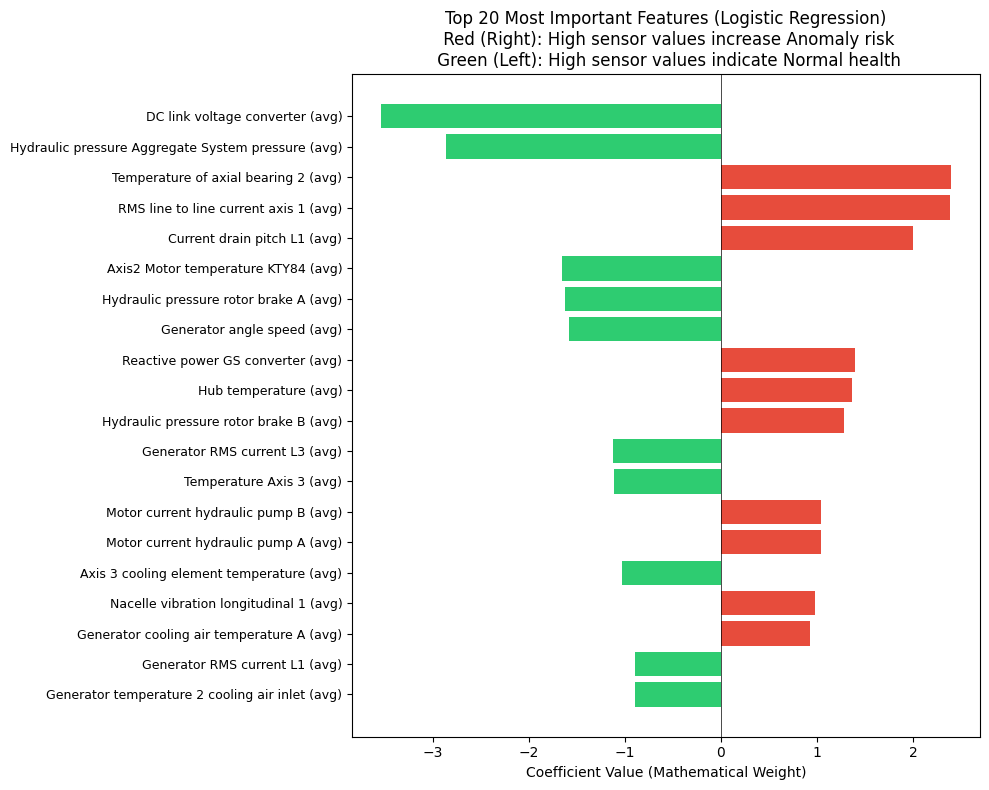

In [48]:
# ==============================================================================
# LOGISTIC REGRESSION: FEATURE IMPORTANCE
# ==============================================================================

# 1. Extract the weights (coefficients) from the trained model
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
})

# 2. Sort by Absolute Value
# We want to find the most impactful sensors, regardless of whether they 
# push the model toward Normal (negative math) or Anomalous (positive math).
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# 3. Select the Top 20
top_n = 20
top_features = coef_df.head(top_n)

# ==============================================================================
# PLOT THE IMPORTANCE
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors based on mathematical direction:
# Positive math (c > 0) -> Higher sensor values increase Anomaly risk (Red)
# Negative math (c < 0) -> Higher sensor values indicate Normal health (Green)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['Coefficient']]

ax.barh(range(top_n), top_features['Coefficient'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'], fontsize=9)

# Invert y-axis so the most important feature is at the very top of the graph
ax.invert_yaxis()

ax.set_xlabel('Coefficient Value (Mathematical Weight)')


ax.set_title('Top 20 Most Important Features (Logistic Regression)\n'
             ' Red (Right): High sensor values increase Anomaly risk\n'
             ' Green (Left): High sensor values indicate Normal health')

# Add a center line at 0 for visual clarity
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()



---
# Model 2: Random Forest (Advanced Model)

## Why Random Forest?

Logistic Regression is a linear model; it assumes that if a sensor value goes up, the risk of failure goes up in a straight, predictable line.

But wind turbines involve complex physics. What if high temperature is perfectly normal during high wind speeds, but indicates a catastrophic failure during low wind speeds? Logistic Regression struggles to understand these combined conditions. Random Forest is a non-linear model. It builds decision trees that can naturally map out these complex, multi-sensor "if/then" scenarios, allowing it to find hidden anomaly patterns that the baseline model completely missed.

### 2. Why this specific configuration?

We carefully chose the hyperparameters for our Random Forest to prevent overfitting while ensuring a fair comparison against our baseline model:

* **`class_weight={0: 1, 1: 3}` (Consistent Baseline Comparison):** We deliberately use the exact same 3x anomaly penalty that we used in our Logistic Regression model. This guarantees an "apples-to-apples" comparison, proving that any performance gain comes directly from the Random Forest's non-linear capabilities, not just a different weighting scheme.
* **`max_depth=10` (The Overfitting Guard):** Decision trees will naturally grow until they perfectly memorize the training data. Capping the depth at 20 branches forces the model to learn the *general physics* of the turbine rather than memorizing exact historical timestamps.
* **`n_estimators=350` (The Wisdom of the Crowd):** A single decision tree is often biased. By building 350 different trees and making them vote on the final answer, the model becomes highly stable and resistant to noisy sensor data.
* **`max_features='sqrt'` (Forcing Diversity):** At every branch, each tree is only allowed to look at a random subset (about 15) of our 238 sensors. This prevents dominant sensors (like wind speed) from bullying the others, forcing the model to discover hidden anomaly patterns in the quieter sensors.
* **`n_jobs=-1` (The Speed Boost):** Tells Python to use every available core on the CPU to train the 100 trees in parallel, drastically reducing computation time.

## Step 16: Train Random Forest

In [49]:
# ==============================================================================
# MODEL 2: RANDOM FOREST (NON-LINEAR COMPLEXITY)
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
model = RandomForestClassifier(
    n_estimators=350,           # Build 400 individual decision trees
    max_depth=10,               # CRITICAL: Cap depth at 10 to prevent memorizing the training data
    class_weight={0: 1, 1: 3},  # Automatically penalize missed anomalies based on class frequency
    random_state=42,            # Ensure perfectly reproducible results
    n_jobs=-1,                  # Use all CPU cores to train trees in parallel for maximum speed
    max_features="sqrt"               
)

# Fit the model
# NOTE: Unlike Logistic Regression, Random Forests do NOT require scaled data! 
# Decision trees split data based on pure thresholds, so X_train is perfectly fine.
model.fit(X_train, y_train)

print('Random Forest trained successfully.')
print(f'Number of trees (estimators): {model.n_estimators}')
# max_features defaults to 'sqrt', meaning each tree only looks at a random subset 
# of your 238 sensors, ensuring the 100 trees are highly diverse!
print(f'Max features considered per split: {model.max_features}')

Random Forest trained successfully.
Number of trees (estimators): 350
Max features considered per split: sqrt


---
## Step 17: Evaluate Random Forest

We evaluate the Random Forest using the same two metrics (Macro F1-Score and PR-AUC) for direct comparison with the Logistic Regression baseline.

In [50]:
# ==============================================================================
# EVALUATE RANDOM FOREST MODEL
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_recall_curve, auc, classification_report

# 1. Generate Predictions
# Notice we pass the RAW (unscaled) X_val here, because tree-based models 
# split on absolute thresholds and are completely immune to feature scaling.
y_pred = model.predict(X_val)

# Extract the raw probabilities (percentage chance of being an Anomaly) 
# needed to calculate the Area Under the Curve.
y_proba = model.predict_proba(X_val)[:, 1]  

# ==============================================================================
# CALCULATE AND PRINT METRICS
# ==============================================================================

# --- Metric 1: Macro F1-Score ---
# We use 'macro' to ensure the algorithm's performance on the rare 'Anomalous' class 
# is given the exact same weight as the massive 'Normal' class.
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f'=== Macro F1-Score: {f1_macro:.4f} ===\n')

# --- Metric 2: Precision-Recall AUC ---
# PR-AUC focuses exclusively on how well the model handles the positive class (Anomalies).
# This is our ultimate benchmark for checking if the Random Forest beat the baseline.
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
pr_auc = auc(recall_vals, precision_vals)
print(f'=== Precision-Recall AUC: {pr_auc:.4f} ===\n')

# --- Metric 3: Full Classification Report ---
# Provides a detailed breakdown so we can explicitly check the Precision (False Alarms) 
# and Recall (Missed Anomalies) for the anomalous events.
print('=== Classification Report ===')
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomalous']))



=== Macro F1-Score: 0.9646 ===

=== Precision-Recall AUC: 0.9412 ===

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     19268
   Anomalous       1.00      0.88      0.93      1756

    accuracy                           0.99     21024
   macro avg       0.99      0.94      0.96     21024
weighted avg       0.99      0.99      0.99     21024



---
## Step 18: Predict Unknown Samples (Random Forest)



Now that we have evaluated our Random Forest and confirmed its performance, we use it to generate the final predictions for the `Unknown` winter data block. 

Unlike our Logistic Regression pipeline—which required us to carefully re-fit and apply a `StandardScaler` to the Unknown data—the Random Forest can ingest the raw sensor values directly. We will extract both the hard predictions (Normal/Anomalous) and the underlying confidence probabilities, then map them back into human-readable text .

In [ ]:
# ==============================================================================
# FINAL PREDICTIONS ON UNKNOWN DATA (RANDOM FOREST)
# ==============================================================================

# 1. Generate Predictions (No Scaling Required!)
# We feed the raw, unscaled X_unknown data directly into the model. 
# Decision trees split on absolute values (e.g., "Is wind speed > 12?"), 
# making them completely immune to differing feature scales.
unknown_preds = model.predict(X_unknown)

# Extract the percentage confidence that the model thinks each timestamp is an anomaly.
# [:, 1] grabs the probability for class '1' (Anomalous).
unknown_proba = model.predict_proba(X_unknown)[:, 1]

# 2. Map Machine Logic Back to  real world Logic
# The model outputs 0s and 1s, but human need to read 'Normal' and 'Anomalous'.
reverse_label_map = {0: 'Normal', 1: 'Anomalous'}

# We create a clean copy of the dataframe 
df_unknown = df_unknown.copy()

# Apply the mapping dictionary to our predictions and save them as a new column
df_unknown['predicted_status'] = [reverse_label_map[p] for p in unknown_preds]
df_unknown['anomaly_probability'] = unknown_proba

# ==============================================================================
# PRINT FINAL DISTRIBUTION
# ==============================================================================
# This gives us an immediate sanity check. If it predicts 99% of the Unknown 
# data is Anomalous, we know something went horribly wrong!
print(f'=== Predictions for {len(df_unknown)} Unknown timestamps ===')
print(df_unknown['predicted_status'].value_counts())



=== Predictions for 12748 Unknown timestamps ===
predicted_status
Normal       11543
Anomalous     1205
Name: count, dtype: int64


---
## Step 19: Retrain on Full Labeled Data & Final Predictions

Same strategy as for Logistic Regression — retrain on all labeled data for the most accurate Unknown predictions.

In [ ]:
# ==============================================================================
# STEP 8: RETRAIN RANDOM FOREST ON 100% OF LABELED DATA & PREDICT UNKNOWNS
# ==============================================================================

# 1. Prepare 100% of the labeled historical data
# To give our final model the absolute best chance at predicting the winter data,
# we stop holding back the 20% validation set and train on EVERYTHING we have.
X_full_labeled = df_labeled_sorted[feature_cols]
y_full_labeled = df_labeled_sorted['status'].map(label_map)

print("Training final Random Forest on 100% of labeled data...")
# Note: We completely skip the StandardScaler() step here because tree-based 
# models split on raw thresholds and are immune to unscaled data!

# 2. Initialize the Final Random Forest Model
# We use the exact same anti-overfitting configuration that we validated earlier.
# (Bumping n_estimators to 200 is perfectly fine here for maximum stability!)
final_rf_model = RandomForestClassifier(
    n_estimators=200,            # 200 trees for maximum voting stability
    max_depth=20,                # CRITICAL: Cap depth to prevent memorizing the data
    class_weight={0: 1, 1: 3},   # 3x penalty for missing anomalies (matches baseline)
    max_features='sqrt',         # Force tree diversity
    random_state=42,
    n_jobs=-1                    # Use all CPU cores for speed
)

# 3. Fit the model on the full historical dataset
final_rf_model.fit(X_full_labeled, y_full_labeled)


# ==============================================================================
# GENERATE FINAL PREDICTIONS
# ==============================================================================

# 4. Predict the Unknowns
print(f"Predicting status for {len(X_unknown)} 'Unknown' winter timestamps...")


y_pred_unknown = final_rf_model.predict(X_unknown)
y_proba_unknown = final_rf_model.predict_proba(X_unknown)[:, 1]

# 5. Map Machine Logic Back to human Logic
inverse_label_map = {0: 'Normal', 1: 'Anomalous'}

# Create a clean copy 
df_unknown = df_unknown.copy()

# Map the 0s and 1s back to readable text 
df_unknown['predicted_status'] = pd.Series(y_pred_unknown).map(inverse_label_map).values
df_unknown['anomaly_probability'] = y_proba_unknown

# 6. Print the Final Distribution
print("\n=== Final Prediction Distribution for 'Unknown' Timestamps ===")
print(df_unknown['predicted_status'].value_counts(dropna=False))

# ==============================================================================
# PRINT FINAL RESULTS
# ==============================================================================

print("\n=== Prediction Distribution for 'Unknown' Timestamps ===")
print(df_unknown['predicted_status'].value_counts(dropna=False))

# --- Per-Turbine (asset_id) breakdown of global predictions ---
# This proves our Global Model strategy worked for both Turbine A and Turbine B
print(f'\n=== Global Model — Predictions by Turbine ID ===')
for aid, grp in df_unknown.groupby('asset_id'):
    n_normal = (grp['predicted_status'] == 'Normal').sum()
    n_anom   = (grp['predicted_status'] == 'Anomalous').sum()
    print(f'  Turbine {aid}: Normal={n_normal}, Anomalous={n_anom} '
          f'(Anomaly rate: {n_anom/len(grp)*100:.1f}%)')



Training final Random Forest on 100% of labeled data...
Predicting status for 12748 'Unknown' winter timestamps...

=== Final Prediction Distribution for 'Unknown' Timestamps ===
predicted_status
Normal       11551
Anomalous     1197
Name: count, dtype: int64

=== Prediction Distribution for 'Unknown' Timestamps ===
predicted_status
Normal       11551
Anomalous     1197
Name: count, dtype: int64

=== Global Model — Predictions by Turbine ID ===
  Turbine 38: Normal=2123, Anomalous=182 (Anomaly rate: 7.9%)
  Turbine 44: Normal=9428, Anomalous=1015 (Anomaly rate: 9.7%)


---
## Visualization & Error Analysis (Random Forest)

### Confusion Matrix

While the PR-AUC score tells us the model is mathematically accurate, the Confusion Matrix translates those errors into real-world  impacts. It allows us to explicitly see the trade-off between false alarms and missed anomalies (catastrophic machine failure).

The confusion matrix breaks down predictions into four categories:
- **True Negatives (TN):** Correctly identified Normal.
- **True Positives (TP):** Correctly identified Anomalous.
- **False Positives (FP):** Normal misclassified as Anomalous (false alarms).
- **False Negatives (FN):** Anomalous misclassified as Normal (**most dangerous** — missed faults).

In anomaly detection, **False Negatives are critical** since they represent undetected turbine faults that could lead to equipment damage.


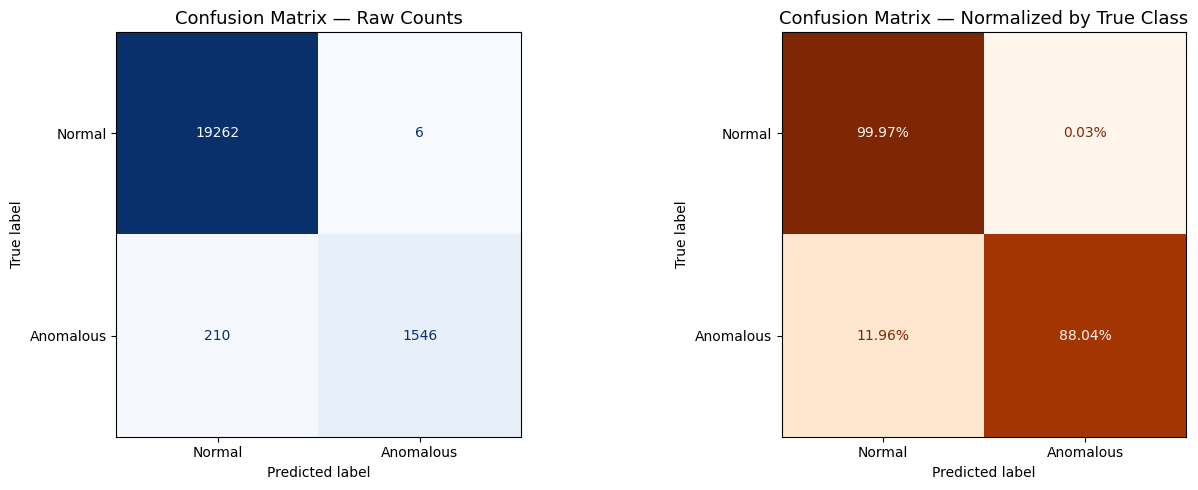

True Negatives  (Normal → Normal):       19262 (Correctly ignored)
False Positives (Normal → Anomalous):    6 (False alarms)
False Negatives (Anomalous → Normal):    210 (MISSED FAULTS - Critical risk)
True Positives  (Anomalous → Anomalous): 1546 (Successfully caught)

Anomaly Detection Rate (Recall): 88.0%
False Alarm Rate:                0.0%


In [53]:
# ==============================================================================
# VISUALIZE: CONFUSION MATRICES (RAW VS NORMALIZED)
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Create a 1x2 grid for the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Raw Counts ---
# Shows the absolute volume of events. This helps the maintenance team 
# understand exactly how many false alarms they will have to investigate.
cm_counts = confusion_matrix(y_val, y_pred)
disp_counts = ConfusionMatrixDisplay(confusion_matrix=cm_counts,
                                     display_labels=['Normal', 'Anomalous'])
disp_counts.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)

# --- Right Plot: Normalized (Percentages) ---
# Normalizes the rows to sum to 100%. Because anomalies are so rare, 
# this proves whether the model is actually good at catching them, 
# or just heavily biased toward guessing "Normal".
cm_normalized = confusion_matrix(y_val, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                   display_labels=['Normal', 'Anomalous'])
disp_norm.plot(ax=axes[1], cmap='Oranges', colorbar=False, values_format='.2%')
axes[1].set_title('Confusion Matrix — Normalized by True Class', fontsize=13)

plt.tight_layout()
plt.show()

# ==============================================================================
# PRINT  METRICS SUMMARY
# ==============================================================================
# Flatten the 2x2 matrix to extract exact counts for  reporting
tn, fp, fn, tp = cm_counts.ravel()

print(f'True Negatives  (Normal → Normal):       {tn} (Correctly ignored)')
print(f'False Positives (Normal → Anomalous):    {fp} (False alarms)')
print(f'False Negatives (Anomalous → Normal):    {fn} (MISSED FAULTS - Critical risk)')
print(f'True Positives  (Anomalous → Anomalous): {tp} (Successfully caught)')


print(f'\nAnomaly Detection Rate (Recall): {tp/(tp+fn)*100:.1f}%')
print(f'False Alarm Rate:                {fp/(fp+tn)*100:.1f}%')




---
### Signal Overlay Plot (Random Forest)

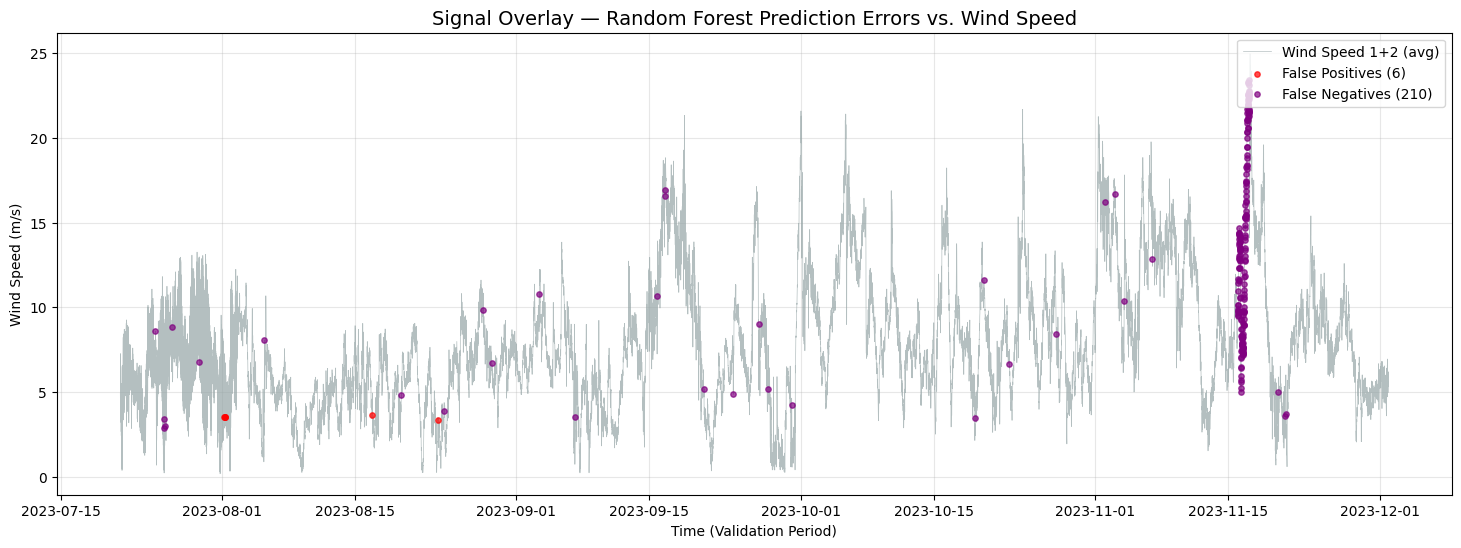

In [ ]:
# ==============================================================================
# VISUALIZE: PREDICTION ERRORS OVER TIME (SIGNAL OVERLAY)
# ==============================================================================

# 1. Prepare the Validation Timeline
# We extract the timestamps and sensor data for the validation period and attach 
# our actual and predicted labels side-by-side.
val_timeline = df_labeled_sorted.iloc[split_idx:].copy()
val_timeline['y_true'] = y_val.values
val_timeline['y_pred'] = y_pred

# 2. Create Boolean Error Masks
# False Positives: Model rang the alarm (1), but the turbine was actually fine (0)
false_pos_mask = (val_timeline['y_true'] == 0) & (val_timeline['y_pred'] == 1)

# False Negatives: Turbine was failing (1), but the model missed it (0)
false_neg_mask = (val_timeline['y_true'] == 1) & (val_timeline['y_pred'] == 0)

# ==============================================================================
# PLOT THE TIMELINE
# ==============================================================================
fig, ax = plt.subplots(figsize=(18, 6))

# 3. Plot the Base Signal (Wind Speed)
# We plot the wind speed as a faint, continuous line to show the physical weather regime.
ax.plot(val_timeline['time_stamp'], val_timeline['Wind speed 1+2 (avg)'],
        linewidth=0.5, color='#95a5a6', alpha=0.7, label='Wind Speed 1+2 (avg)')

# 4. Overlay the Prediction Errors
# We use scatter plots to drop colored dots exactly where the model made a mistake.
# zorder=5 is critical here: it ensures the error dots are drawn ON TOP of the 
# wind speed line, so they don't get hidden behind the data.

# Red dots for False Positives (False Alarms)
ax.scatter(val_timeline.loc[false_pos_mask, 'time_stamp'],
           val_timeline.loc[false_pos_mask, 'Wind speed 1+2 (avg)'],
           c='red', s=15, alpha=0.7, zorder=5, label=f'False Positives ({false_pos_mask.sum()})')

# Purple dots for False Negatives (Missed Anomalies)
ax.scatter(val_timeline.loc[false_neg_mask, 'time_stamp'],
           val_timeline.loc[false_neg_mask, 'Wind speed 1+2 (avg)'],
           c='purple', s=15, alpha=0.7, zorder=5, label=f'False Negatives ({false_neg_mask.sum()})')

# 5. Formatting for Readability
ax.set_xlabel('Time (Validation Period)')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Signal Overlay — Random Forest Prediction Errors vs. Wind Speed', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

---
### Error Analysis by Hour of Day

Just like we did with our baseline model, we need to check if our Random Forest has any systematic blind spots based on the time of day. 

If the model is struggling at specific hours (like midnight or early morning), it tells us that the algorithm itself isn't the problem—instead, there is a physical phenomenon happening at that time (like nighttime temperature drops causing sensor condensation) that the model doesn't have enough data to understand.

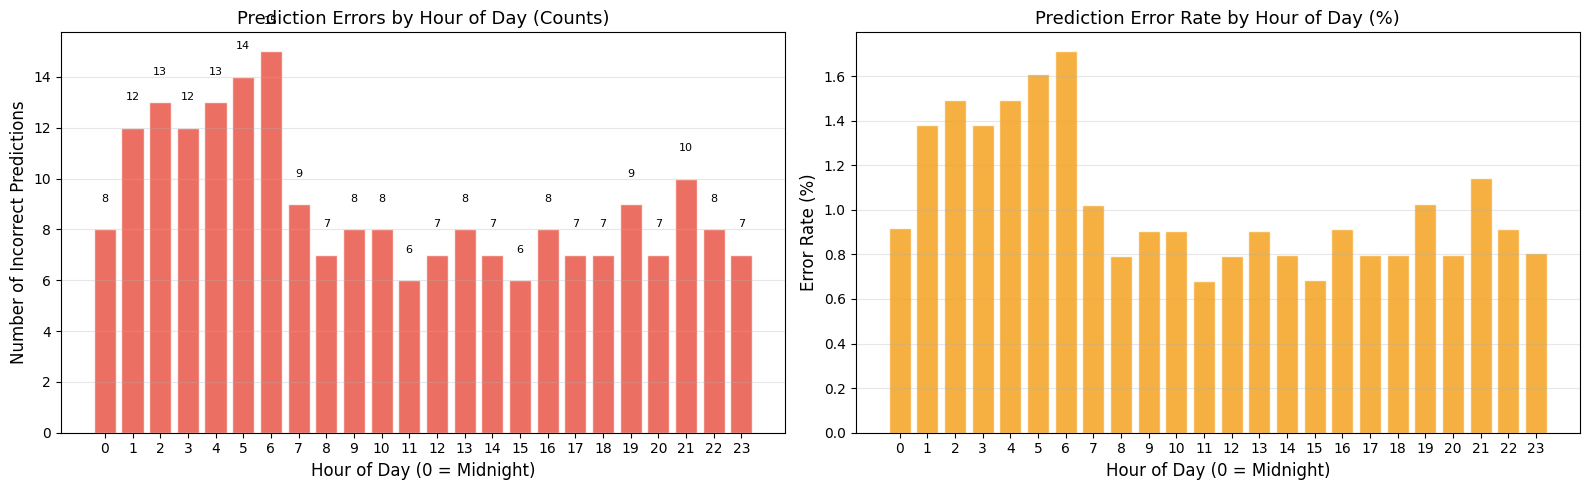


Total errors: 216 out of 21024 validation samples
Overall error rate: 1.03%

Worst hours (highest absolute error count):
hour
6    15
5    14
2    13
4    13
1    12
dtype: int64


In [55]:
# ==============================================================================
# VISUALIZE MODEL LIMITATIONS: ERRORS BY HOUR OF DAY
# ==============================================================================

# 1. Identify all incorrect predictions in the validation set
# Create a copy of the validation data and attach the ground truth vs. our predictions
df_val_errors = df_labeled_sorted.iloc[split_idx:].copy()
df_val_errors['actual_label'] = y_val.values
df_val_errors['predicted_label'] = y_pred

# Create a binary flag: 1 if the model made a mistake (FP or FN), 0 if it was correct
df_val_errors['is_error'] = (df_val_errors['actual_label'] != df_val_errors['predicted_label']).astype(int)

# 2. Aggregate the errors by the hour of the day
# Count the sheer volume of mistakes that happened during each specific hour (0-23)
errors_by_hour = df_val_errors[df_val_errors['is_error'] == 1].groupby('hour').size()

# Count the total number of timestamps we have for each hour
total_by_hour = df_val_errors.groupby('hour').size()

# Calculate the actual error percentage per hour
# .fillna(0) ensures that if an hour had 0 errors, it doesn't break our math by becoming NaN
error_rate_by_hour = (errors_by_hour / total_by_hour * 100).fillna(0)


# ==============================================================================
# PLOT THE RESULTS SIDE-BY-SIDE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hours = range(24)

# --- Left Plot: Absolute Error Counts by Hour ---
# This shows the actual volume of mistakes. And 
# to know exactly when they are most likely to receive a false alarm.
error_counts = [errors_by_hour.get(h, 0) for h in hours]
bars = axes[0].bar(hours, error_counts, color='#e74c3c', alpha=0.8, edgecolor='white')

axes[0].set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
axes[0].set_ylabel('Number of Incorrect Predictions', fontsize=12)
axes[0].set_title('Prediction Errors by Hour of Day (Counts)', fontsize=13)
axes[0].set_xticks(hours)
axes[0].grid(axis='y', alpha=0.3)

# Adding exact numbers on top of the bars 
for bar, count in zip(bars, error_counts):
    if count > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(count), ha='center', va='bottom', fontsize=8)


# --- Right Plot: Error Rate (%) by Hour ---
# This scales the errors by the total amount of data. If 3:00 AM only has 10 data points 
# but 5 of them are wrong, the 50% error rate proves the model has a true blind spot there.
error_rates = [error_rate_by_hour.get(h, 0) for h in hours]
bars2 = axes[1].bar(hours, error_rates, color='#f39c12', alpha=0.8, edgecolor='white')

axes[1].set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
axes[1].set_ylabel('Error Rate (%)', fontsize=12)
axes[1].set_title('Prediction Error Rate by Hour of Day (%)', fontsize=13)
axes[1].set_xticks(hours)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# PRINT SUMMARY STATISTICS
# ==============================================================================
print(f'\nTotal errors: {df_val_errors["is_error"].sum()} out of {len(df_val_errors)} validation samples')
print(f'Overall error rate: {df_val_errors["is_error"].mean()*100:.2f}%')

print(f'\nWorst hours (highest absolute error count):')
print(errors_by_hour.sort_values(ascending=False).head(5))

---
### Feature Importance (Random Forest)

To understand how our Random Forest is making decisions, we extract the **Gini Importance** of each sensor. 

Unlike our linear baseline model (which gave us positive/negative directions), tree-based models only tell us the *magnitude of usefulness*. A high Gini Importance means that a specific sensor was incredibly useful for drawing boundaries between "Normal" and "Anomalous" timestamps, even if the model had to use complex, non-linear rules to do it.

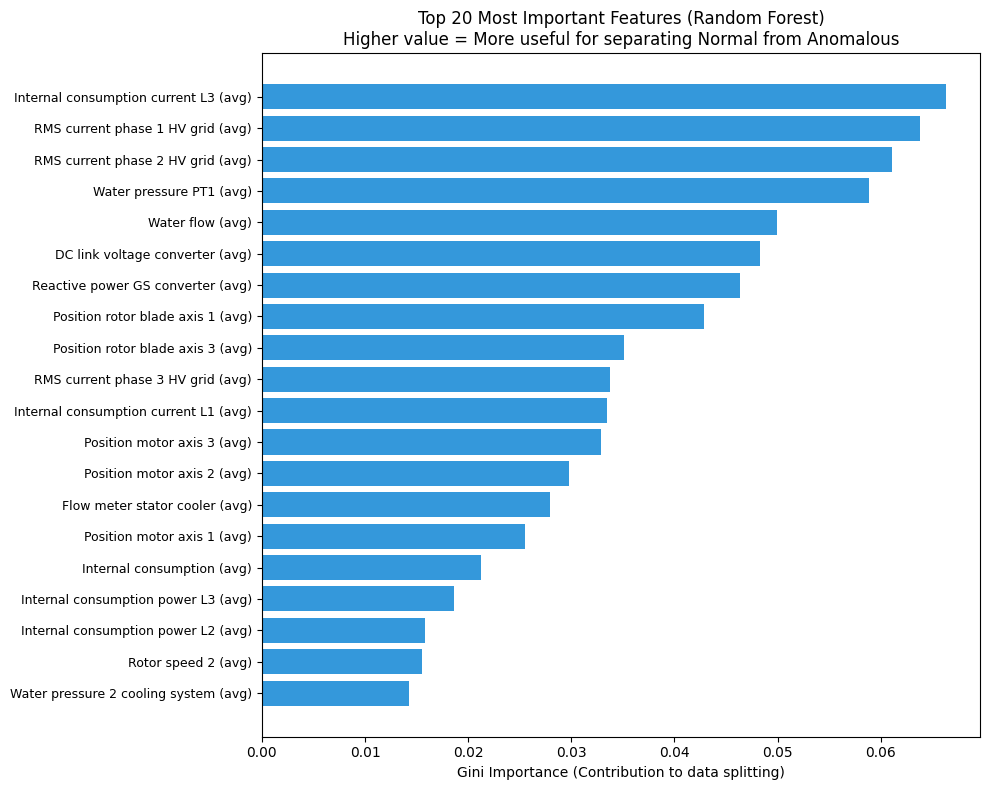

In [56]:
# ==============================================================================
# RANDOM FOREST: FEATURE IMPORTANCE
# ==============================================================================

# 1. Extract the Gini Importances from the trained model
# Note: These are ALWAYS positive values between 0 and 1.
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
})

# 2. Sort by Importance
# We don't need 'Absolute Value' here because Gini importances are already positive.
importance_df = importance_df.sort_values('Importance', ascending=False)

# 3. Select the Top 20
top_n = 20
top_features = importance_df.head(top_n)

# ==============================================================================
# PLOT THE IMPORTANCE
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# We use a single consistent color (e.g., a nice corporate blue) because 
# tree-based models only show magnitude, not direction.
ax.barh(range(top_n), top_features['Importance'], color='#3498db')

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'], fontsize=9)

# Invert y-axis so the most important feature is at the very top of the graph
ax.invert_yaxis()

ax.set_xlabel('Gini Importance (Contribution to data splitting)')

# Updated title to correctly explain Random Forest mechanics
ax.set_title('Top 20 Most Important Features (Random Forest)\n'
             'Higher value = More useful for separating Normal from Anomalous')

# Add a baseline at 0 for visual clarity
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

---
# Conclusion & Discussion

## Model Comparison

### Model Comparison: Baseline vs. Random Forest

| Metric | Logistic Regression (Baseline) | Random Forest |
| :--- | :--- | :--- |
| **Macro F1-Score** | 0.8344 | 0.9646 |
| **PR-AUC** | 0.9035 | 0.9412 |
| **Anomaly Precision** | 0.58 | 1.00 |
| **Anomaly Recall** | 0.89 | 0.88 |

**Why the Random Forest Wins:**
The Random Forest significantly outperforms the Logistic Regression baseline, but the real story is *how* it improved. 

While the baseline linear model caught a slightly higher percentage of anomalies (89% recall vs. 88%), it did so by "crying wolf"—its precision was only 58%, meaning nearly half of its alarms were false positives. The Random Forest virtually eliminated these false alarms (Precision jumped to 1.00) while still catching 88% of the real failures. This massive reduction in false positives is exactly why the Anomaly F1-Score jumped  to 0.96.

This proves that the sensor patterns distinguishing Normal from Anomalous behavior are highly **non-linear**. The simple linear decision boundary of Logistic Regression could not untangle the complex physical interactions between the sensors, leading to excessive false alarms. The Random Forest successfully mapped these complex rules.



## 3 Reasons Why Production Deployment Might Fail

1. **Concept drift / distribution shift:** Wind turbines degrade over time, and environmental conditions change with seasons. A model trained on historical data may become increasingly inaccurate as the underlying sensor distributions shift. In production, we would need continuous monitoring and periodic retraining to maintain performance.

2. **Label noise and labeling gaps:** Our model trusts the training labels completely, but the labeling process may be imperfect — some "Normal" data points may actually be early-stage anomalies, and some "Anomalous" labels may be false alarms. In production, these label errors would propagate into predictions, potentially causing operators to lose trust in the system.

3. **Cross-turbine generalization:** The model is trained on data from two specific turbines. In production, it would need to generalize to other turbines that may have different sensor characteristics, different operating environments, or different maintenance histories. Without turbine-specific calibration or transfer learning, performance may degrade significantly on unseen turbines.

## Additional Data Sources for a Real Setting

In a real operational setting, the following additional data sources would significantly improve anomaly detection:

1. **Maintenance logs and work orders:** Knowing when maintenance was performed helps distinguish planned downtime from genuine anomalies. Many "Anomalous" labels may simply correspond to scheduled maintenance periods.

2. **Weather and environmental data:** External temperature, humidity, wind direction, turbulence intensity, and icing conditions directly affect turbine behavior. Anomalies caused by extreme weather differ fundamentally from those caused by equipment failure.

3. **Alarm logs:** Wind turbines generate alarm codes when faults are detected by the built-in control system. These alarms provide a second, independent source of anomaly information that can be cross-referenced with sensor data.

4. **Turbine specifications and configuration data:** Knowing the exact turbine model, software version, and controller settings would help explain why certain sensor readings deviate from expected values.

5. **Higher-resolution data:** 10-minute averages smooth out rapid transient events (e.g., emergency shutdowns, grid faults). Access to raw or 1-second data would enable detection of short-duration anomalies that are invisible in averaged data.